# 第一讲：Pandas 数据结构 × Vibe Coding 完整工具体系

**课程**：Python 进阶 · 计算机学院 · CloudStudio + CodeBuddy

**受众**：有 Python 基础、希望用 AI 驱动数据分析的同学

**前置条件**：会 Python 基础语法（列表、字典、函数）；已注册 CloudStudio 账号

## 学习目标

完成本讲后，你能做到：

- 创建并操作 Pandas Series 和 DataFrame
- 读写 CSV / Excel 文件，处理缺失值
- 用 Matplotlib 绘制数据可视化图表
- 掌握 Vibe Coding 核心工具链：两段式 Prompt、Rules、上下文工程、Inline Edit

## 课程大纲

1. Vibe Coding 工具体系概览（范式 + 工具全景）
2. Pandas Series × 两段式 Prompt（先氛围后约束）
3. Pandas DataFrame × Rules 规则文件（锁定编码 DNA）
4. 数据文件操作 × 上下文工程（@文件引用 + 四层级）
5. 数据可视化 × Inline Edit（Cmd+K + Diff 审查）

---

## Part 0：Vibe Coding 完整工具体系概览

### 0.1 编程范式的三次革命

| 时代                     | 抽象层级                    | 程序员做的事                  |
| ------------------------ | --------------------------- | ----------------------------- |
| 汇编 → C                 | 机器指令 → 逻辑语句         | 写每一条机器指令              |
| C → Python               | 内存管理 → 业务逻辑         | 管内存、写指针                |
| Python → **Vibe Coding** | 业务逻辑 → 自然语言意图     | 描述"要什么"，AI 实现"怎么做" |

每次革命的本质都是抽象层级的提升。

### 0.2 你的新身份：AI 指挥官

| 旧身份：代码工人 | 新身份：AI 指挥官    |
| ---------------- | -------------------- |
| 手写每一行代码   | 描述意图，AI 实现    |
| 靠记忆 API 文档  | 靠语言表达需求       |
| 调试是主要工作   | 审查和迭代是主要工作 |
| 知道怎么写       | 知道要什么、对不对   |

### 0.3 Vibe Coding 核心工具链（本讲覆盖）

| 工具/方法                         | 解决什么问题                       | 对应 Part |
| --------------------------------- | ---------------------------------- | --------- |
| **两段式 Prompt**（先氛围后约束） | AI 输出方向跑偏                    | Part 1-4  |
| **Rules 规则文件**                | 每次生成风格不一致                 | Part 2    |
| **上下文工程**（@文件引用）       | AI 不了解你的数据，乱猜列名        | Part 3    |
| **Inline Edit**（Cmd+K）          | 小改动要重开对话，打断心流         | Part 4    |
| **Diff 审查清单**                 | 接受 AI 修改前不知道改了啥         | Part 4    |

### 0.4 三个危险信号

当你出现以下行为时，说明还没进入 Vibe Coding 状态：

| 危险信号                 | 本质问题                   | 正确做法                          |
| ------------------------ | -------------------------- | --------------------------------- |
| 开始手动改 AI 生成的代码 | 退回"代码工人"模式         | 用自然语言说清楚修改点，让 AI 改  |
| 开始去搜索语法细节       | 陷入旧思路时间黑洞         | 把问题描述给 AI，请它解释并给方案 |
| 觉得描述需求比写代码慢   | 还在适应期，表达方式未成型 | 坚持"先目标、后约束"，速度会提升  |

In [1]:
# 环境初始化
# 在 CodeBuddy 中输入以下 Prompt 完成环境配置（这是你的第一次 Vibe Coding！）：
#   帮我配置一个 Python 数据分析环境，安装 pandas、matplotlib、openpyxl、numpy
#   安装skill:https://agenticskills.io/skills/jupyter-notebook，以后写notebook你要用它

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

# 设置中文字体（自动适配 macOS / Windows / Linux）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print('环境就绪 ✓')


pandas  2.3.3
numpy   2.2.1
环境就绪 ✓


---

## Part 1：Pandas Series × 两段式 Prompt

**学习目标**：创建 Series、操作索引、调用统计方法；同时掌握"先氛围后约束"的两段式 Prompt 节奏。

### 工具讲解：两段式 Prompt 方法

核心原则：先描述"感觉"，再给"约束"。不要第一句就报参数名。

```
Round 1（氛围层）定方向，不要求精确
示例：创建一组本周各城市空气质量指数（AQI）的 Series，展示基本统计信息

Round 2（约束层）渐进收紧，补细节
示例：在保持上面代码的前提下，增加：
  1. 用城市名作为 index
  2. 打印 max、min、mean，并指出哪个城市空气最差
  3. 所有变量名用英文，注释用中文
```

卡点提示：如果 AI 生成的 Series 没有中文索引，不要手动改代码，用 Round 2 Prompt 重新描述约束。

### 1.1 三种创建方式（入门层：小数据讲概念）

In [2]:
import pandas as pd

# 方式一：列表（自动整数索引）
s1 = pd.Series([89, 45, 67, 112, 78])  # 5 个城市 AQI（无标签）

# 方式二：字典（键自动成为 index）—— 最推荐，语义清晰
s2 = pd.Series({'北京': 89, '上海': 45, '广州': 67, '成都': 112, '西安': 78})  # 某日各城市 AQI

# 方式三：常量广播
s3 = pd.Series(75, index=['北京', '上海', '广州'])  # 假设三城市优良线（AQI<=75）

print('=== 方式一（整数索引）===')
print(s1)
print('\n=== 方式二（字典，推荐）===')
print(s2)
print('\n=== 方式三（常量广播）===')
print(s3)

=== 方式一（整数索引）===
0     89
1     45
2     67
3    112
4     78
dtype: int64

=== 方式二（字典，推荐）===
北京     89
上海     45
广州     67
成都    112
西安     78
dtype: int64

=== 方式三（常量广播）===
北京    75
上海    75
广州    75
dtype: int64


### 1.2 关键属性与统计方法（两段式 Prompt 结果演示）

**Round 1 → Round 2 生成的满分代码：**


In [3]:
import pandas as pd

# 两段式 Prompt Round 2 约束后的结果
city_aqi = pd.Series(
    {'北京': 89, '上海': 45, '广州': 67, '成都': 112, '西安': 78},
    name='某日各城市AQI'
)

# 关键属性
print('values:', city_aqi.values)
print('index: ', city_aqi.index.tolist())
print('dtype: ', city_aqi.dtype)

# 统计方法
print(f'\nAQI最高：{city_aqi.max()}（{city_aqi.idxmax()}）')
print(f'AQI最低：{city_aqi.min()}（{city_aqi.idxmin()}）')
print(f'平均AQI：{city_aqi.mean():.1f}')
print('\n描述性统计：')
print(city_aqi.describe())

values: [ 89  45  67 112  78]
index:  ['北京', '上海', '广州', '成都', '西安']
dtype:  int64

AQI最高：112（成都）
AQI最低：45（上海）
平均AQI：78.2

描述性统计：
count      5.000000
mean      78.200000
std       24.933913
min       45.000000
25%       67.000000
50%       78.000000
75%       89.000000
max      112.000000
Name: 某日各城市AQI, dtype: float64


### 1.3 索引操作与条件筛选

Inline Edit 技巧（Cmd+K）：选中下方 loc/iloc 代码块，按 Cmd+K，输入"改为筛选出AQI大于75的城市（轻度污染及以上）"，查看 Diff 后 Accept。

In [4]:
import pandas as pd

s = pd.Series({'北京': 89, '上海': 45, '广州': 67, '成都': 112, '西安': 78, '深圳': 55, '杭州': 93})

# 标签索引
print('北京AQI:', s['北京'])
print('北京+成都:', s[['北京', '成都']].tolist())

# 条件筛选
polluted = s[s > 75]  # AQI > 75 的城市（轻度污染及以上）
print('\n轻度污染及以上城市：')
print(polluted)

# 排序
print('\nAQI 从高到低：')
print(s.sort_values(ascending=False))

北京AQI: 89
北京+成都: [89, 112]

轻度污染及以上城市：
北京     89
成都    112
西安     78
杭州     93
dtype: int64

AQI 从高到低：
成都    112
杭州     93
北京     89
西安     78
广州     67
深圳     55
上海     45
dtype: int64


### 1.4 真实数据初体验：从航天贸易数据提取 Series

**应用层**：用航天进出口额.xlsx 演示 Series 在真实数据中的形态。
提取「日本进口 2022-01 ~ 2023-12 共 24 个月」的贸易额 Series。


In [5]:
import pandas as pd

# 读取航天数据（Sheet0）
df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')

# 解析指标列：进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

# 筛选：日本进口当期数据
row = df[(df['国家']=='日本') & (df['方向']=='进口额')].iloc[0]

# 提取 24 个月份列为 Series
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]
japan_series = pd.Series({c: row[c] for c in month_cols}, name='日本进口额（万元）')

print('=== 日本进口 24 个月贸易额 Series ===')
print(japan_series.head(12))
print('\n统计摘要：')
print(f'月均：{japan_series.mean():.1f} 万元')
print(f'极差：{japan_series.max() - japan_series.min():.1f} 万元')
print(f'缺失值：{japan_series.isnull().sum()} 个')


=== 日本进口 24 个月贸易额 Series ===
2022-01    2653.87
2022-02    1473.53
2022-03    1739.32
2022-04     690.00
2022-05    2964.17
2022-06     228.00
2022-07    1686.87
2022-08    1304.00
2022-09    2179.76
2022-10    1879.46
2022-11    2675.14
2022-12    1890.39
Name: 日本进口额（万元）, dtype: float64

统计摘要：
月均：1853.1 万元
极差：3912.9 万元
缺失值：0 个


### 1.5 统计方法全景（真实数据场景）

Series 常用统计方法一览，结合日本进口数据演示：


In [6]:
# 统计方法全景
s = japan_series.dropna()  # 先剔除缺失值

print('=== 统计方法全景 ===')
print(f'sum()    总和：{s.sum():.1f}')
print(f'mean()   均值：{s.mean():.1f}')
print(f'std()    标准差：{s.std():.1f}')
print(f'median() 中位数：{s.median():.1f}')
print(f'min()    最小值：{s.min():.1f}')
print(f'max()    最大值：{s.max():.1f}')
print(f'quantile(0.25) 下四分位：{s.quantile(0.25):.1f}')
print(f'quantile(0.75) 上四分位：{s.quantile(0.75):.1f}')

# value_counts() 对离散值有用，这里演示按区间分组
print('\n按区间分组（每500万元一档）：')
bins = pd.cut(s, bins=[0,500,1000,2000,3000,5000])
print(bins.value_counts().sort_index())


=== 统计方法全景 ===
sum()    总和：44475.1
mean()   均值：1853.1
std()    标准差：881.9
median() 中位数：1809.4
min()    最小值：183.1
max()    最大值：4096.0
quantile(0.25) 下四分位：1416.7
quantile(0.75) 上四分位：2162.4

按区间分组（每500万元一档）：
日本进口额（万元）
(0, 500]         2
(500, 1000]      1
(1000, 2000]    14
(2000, 3000]     5
(3000, 5000]     2
Name: count, dtype: int64


### 1.6 时间序列初探：shift 与 rolling

贸易数据天然是时间序列，演示 `.shift()`（滞后）和 `.rolling()`（滚动窗口）。


In [7]:
# 时间序列操作
s = japan_series.dropna()

# shift：对比本月与上月
s_last = s.shift(1)
s_change = s - s_last
print('=== 环比增长（本月 - 上月）===')
print(s_change.head(6))

# rolling：3 个月移动平均
s_ma3 = s.rolling(3).mean()
print('\n=== 3 个月移动平均 ===')
print(s_ma3.head(6))


=== 环比增长（本月 - 上月）===
2022-01        NaN
2022-02   -1180.34
2022-03     265.79
2022-04   -1049.32
2022-05    2274.17
2022-06   -2736.17
Name: 日本进口额（万元）, dtype: float64

=== 3 个月移动平均 ===
2022-01            NaN
2022-02            NaN
2022-03    1955.573333
2022-04    1300.950000
2022-05    1797.830000
2022-06    1294.056667
Name: 日本进口额（万元）, dtype: float64


### 🏋️ 练习 1

用两段式 Prompt 让 CodeBuddy 生成一组 8 个城市的气温 Series，要求：

1. Round 1：描述「一组城市气温数据，展示统计信息」
2. Round 2：加约束「city 名用中文，计算极差（max-min），找出最热城市」

**完成标准**：代码运行无报错，能说出 `values` 和 `index` 的区别。


---

## Part 2：Pandas DataFrame × Rules 规则文件

**学习目标**：掌握 DataFrame 的创建与核心操作；用 Rules 文件锁定 AI 的编码风格，让每次生成的代码都符合团队规范。

### 工具讲解：Rules —— 锁定 AI 的编码 DNA

**配置方法**：在项目根目录创建 `.codebuddy/rules/python-style.md`，内容如下：

```markdown
# Python 数据分析编码规范（Rules）

## 命名规范

- 变量名：英文 snake_case（如 df_scores、course_series）
- 注释：全部使用中文

## Pandas 规范

- 禁止用 for 循环对 DataFrame 逐行处理，必须用向量化操作
- DataFrame 修改必须用 .copy() 避免 SettingWithCopyWarning
- 读取含中文的 CSV 必须加 encoding='utf-8-sig'

## 可视化规范

- 必须设置中文字体：plt.rcParams['font.sans-serif']
- 图表必须有标题（set_title）和轴标签（set_xlabel/set_ylabel）
```

> **效果**：配置后，每次对话 AI 都会自动遵守这些规则，无需每次重复说明。

### 2.1 DataFrame 创建与基本属性（入门层：小数据）


In [8]:
import pandas as pd

# 方式一：字典创建（最常用）
df = pd.DataFrame({
    '产品': ['耳机', '键盘', '鼠标', '显示器', '摄像头', '麦克风'],
    '一季度': [1200, 980, 1560, 2300, 890, 670],
    '二季度': [1450, 1120, 1820, 2100, 1040, 750],
    '三季度': [1680, 890, 2010, 2450, 960, 820]
})

# 基本属性
print('形状:', df.shape)
print('列名:', df.columns.tolist())
print('数据类型:\n', df.dtypes)
print('\n前3行:')
print(df.head(3))
print('\n描述性统计:')
print(df.describe())

形状: (6, 4)
列名: ['产品', '一季度', '二季度', '三季度']
数据类型:
 产品     object
一季度     int64
二季度     int64
三季度     int64
dtype: object

前3行:
   产品   一季度   二季度   三季度
0  耳机  1200  1450  1680
1  键盘   980  1120   890
2  鼠标  1560  1820  2010

描述性统计:
               一季度          二季度          三季度
count     6.000000     6.000000     6.000000
mean   1266.666667  1380.000000  1468.333333
std     589.632654   509.313263   680.453280
min     670.000000   750.000000   820.000000
25%     912.500000  1060.000000   907.500000
50%    1090.000000  1285.000000  1320.000000
75%    1470.000000  1727.500000  1927.500000
max    2300.000000  2100.000000  2450.000000


### 2.2 核心操作：选列、筛选、排序、新增列

| 操作     | 代码                                                              | 说明           |
| -------- | ----------------------------------------------------------------- | -------------- |
| 选单列   | `df['一季度']`                                                    | 返回 Series    |
| 选多列   | `df[['产品', '一季度']]`                                          | 返回 DataFrame |
| 条件筛选 | `df[df['一季度'] > 1000]`                                         | 布尔索引       |
| 排序     | `df.sort_values('季度合计', ascending=False)`                     | 降序排列       |
| 新增列   | `df['季度合计'] = df['一季度'] + df['二季度'] + df['三季度']`     | 向量化计算     |
| 精确定位 | `df.loc[0]` / `df.iloc[1:3]`                                      | 标签 / 位置    |

**Rules 提醒**：新增列用向量化，禁止用 for 循环！

In [9]:
import pandas as pd

df = pd.DataFrame({
    '产品': ['耳机', '键盘', '鼠标', '显示器', '摄像头', '麦克风'],
    '一季度': [1200, 980, 1560, 2300, 890, 670],
    '二季度': [1450, 1120, 1820, 2100, 1040, 750],
    '三季度': [1680, 890, 2010, 2450, 960, 820]
})

# 新增季度合计列（向量化，符合 Rules）
df['季度合计'] = df['一季度'] + df['二季度'] + df['三季度']

# 筛选一季度>1000 的产品
df_hot = df[df['一季度'] > 1000].copy()
print('一季度销售额超过1000万的产品：')
print(df_hot[['产品', '一季度', '季度合计']])

# 按季度合计降序排列
df_sorted = df.sort_values('季度合计', ascending=False)
print('\n按季度合计排名：')
print(df_sorted[['产品', '季度合计']].reset_index(drop=True))

一季度销售额超过1000万的产品：
    产品   一季度  季度合计
0   耳机  1200  4330
2   鼠标  1560  5390
3  显示器  2300  6850

按季度合计排名：
    产品  季度合计
0  显示器  6850
1   鼠标  5390
2   耳机  4330
3   键盘  2990
4  摄像头  2890
5  麦克风  2240


### 2.3 真实数据：读取航天贸易 DataFrame 并解析指标列

**应用层**：用航天数据演示 DataFrame 读取、列解析、筛选、排序。


In [10]:
import pandas as pd

# 读取航天数据
df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')

# 解析指标列
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

# 月份列
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]

print('=== 航天数据基本信息 ===')
print(f'行数：{len(df)}，列数：{len(df.columns)}')
print(f'方向：{df["方向"].unique().tolist()}')
print(f'国家数：{df["国家"].nunique()}')
print('\n前5行（部分列）：')
print(df[['方向', '国家'] + month_cols[:6]].head())


=== 航天数据基本信息 ===
行数：76，列数：31
方向：['进口额', '出口额']
国家数：42

前5行（部分列）：
    方向    国家  2022-01  2022-02  2022-03  2022-04  2022-05  2022-06
0  进口额    印度   288.13   601.83   277.40    937.0   460.15    278.0
1  进口额  中国香港     5.54     1.52      NaN      NaN     0.92     11.0
2  进口额    日本  2653.87  1473.53  1739.32    690.0  2964.17    228.0
3  进口额  马来西亚  1668.97   852.08  1181.90    851.0   796.75    599.0
4  进口额  中国台湾  1189.64   421.17   955.36    316.0  1415.12   1179.0


### 2.4 新增列：年度合计与月均值

向量化计算各国 24 个月的总计与月均值。


In [11]:
# 新增列：24 个月合计、月均值
df['年度合计'] = df[month_cols].sum(axis=1)
df['月均值'] = df[month_cols].mean(axis=1)

# 筛选进口，按年度合计排序 Top10
df_import = df[df['方向'] == '进口额'].copy()
df_top10 = df_import.nlargest(10, '年度合计')

print('=== 进口 Top10 来源国 ===')
print(df_top10[['国家', '年度合计', '月均值']].reset_index(drop=True))


=== 进口 Top10 来源国 ===
    国家        年度合计            月均值
0   欧盟  9323854.78  388493.949167
1   法国  5203221.11  216800.879583
2   美国  5061660.21  210902.508750
3   德国  3820897.37  159204.057083
4  加拿大   558497.86   23270.744167
5   英国   266853.18   11118.882500
6  俄罗斯   164357.63    6848.234583
7  意大利   126055.40    5252.308333
8  西班牙    96361.38    4015.057500
9   韩国    82467.32    3436.138333


### 2.5 分组聚合：groupby

按方向分组，统计进出口总额差异。


In [12]:
# 分组聚合
df_grouped = df.groupby('方向')[['年度合计']].agg(['sum', 'mean', 'count'])
print('=== 按方向分组统计 ===')
print(df_grouped)

# 按国家分组（仅进口），看各国月度波动
df_import = df[df['方向'] == '进口额'].copy()
df_import['月标准差'] = df_import[month_cols].std(axis=1)
df_volatile = df_import.nlargest(5, '月标准差')
print('\n=== 进口月度波动最大的5个国家 ===')
print(df_volatile[['国家', '月均值', '月标准差']].reset_index(drop=True))


=== 按方向分组统计 ===
            年度合计                     
             sum           mean count
方向                                   
出口额  10134050.28  247171.958049    41
进口额  24939359.41  712553.126000    35

=== 进口月度波动最大的5个国家 ===
    国家            月均值           月标准差
0   欧盟  388493.949167  224512.688959
1   法国  216800.879583  160436.404792
2   美国  210902.508750  108718.494279
3   德国  159204.057083   98198.086472
4  加拿大   23270.744167   36007.245487


### 2.6 宽转长：melt

将 24 个月份列转为长格式，便于时间序列分析。


In [13]:
# melt 宽转长
df_long = df.melt(
    id_vars=['方向', '国家'],
    value_vars=month_cols,
    var_name='月份',
    value_name='贸易额'
)

print('=== 长格式示例（日本前6行）===')
print(df_long[df_long['国家']=='日本'].head(6))


=== 长格式示例（日本前6行）===
      方向  国家       月份      贸易额
2    进口额  日本  2022-01  2653.87
38   出口额  日本  2022-01  9663.76
78   进口额  日本  2022-02  1473.53
114  出口额  日本  2022-02  9925.75
154  进口额  日本  2022-03  1739.32
190  出口额  日本  2022-03  6362.97


### 2.7 等级分类：for 循环 vs 向量化

Rules 强制要求：禁止 for 循环，必须向量化。运行下面的对比，体会性能和代码清晰度的差异。


In [14]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    '产品': ['耳机', '键盘', '鼠标', '显示器', '摄像头', '麦克风'],
    '一季度': [1200, 980, 1560, 2300, 890, 670],
    '二季度': [1450, 1120, 1820, 2100, 1040, 750],
    '三季度': [1680, 890, 2010, 2450, 960, 820]
})
df['季度合计'] = df['一季度'] + df['二季度'] + df['三季度']

# 违反 Rules：for 循环逐行处理（AI 若这样写，立刻用 Prompt 要求改掉）
level_loop = []
for total in df['季度合计']:
    if total >= 6000:
        level_loop.append('A')
    elif total >= 4000:
        level_loop.append('B')
    else:
        level_loop.append('C')

# 符合 Rules：np.select 向量化（Rules 约定后 AI 自动生成此写法）
conditions = [df['季度合计'] >= 6000, df['季度合计'] >= 4000]
choices = ['A', 'B']
df['销售等级'] = np.select(conditions, choices, default='C')

print(df[['产品', '季度合计', '销售等级']])

    产品  季度合计 销售等级
0   耳机  4330    B
1   键盘  2990    C
2   鼠标  5390    B
3  显示器  6850    A
4  摄像头  2890    C
5  麦克风  2240    C


### 🏋️ 练习 2

用 Rules + Prompt 完成以下任务（基于航天数据）：

1. 筛选「出口额」数据，计算各国年度合计
2. 用向量化给出口额分级：年度合计>=100000为"大额"，>=50000为"中额"，其余为"小额"
3. 统计各级别国家数量

**完成标准**：代码无 for 循环，运行结果正确。


---

## Part 3：数据文件操作 × 上下文工程

**学习目标**：掌握 CSV/Excel 读写和缺失值处理；理解上下文四层级，用 @文件引用 让 AI 生成精准代码。

### 工具讲解：上下文的四个层级

上下文的精准度决定 AI 的输出质量：相关信息要注入，无关噪声要排除。

| 层级       | 来源           | 控制方式                 | Pandas 场景对应              |
| ---------- | -------------- | ------------------------ | ---------------------------- |
| **系统层** | Rules 文件     | 编辑 `.codebuddy/rules/` | 自动载入编码规范             |
| **会话层** | 当前对话历史   | 开新对话清空             | 重新分析时新开对话           |
| **指令层** | `@` 引用       | 主动选择文件             | `@航天进出口额.xlsx` 让 AI 看到列名 |
| **隐式层** | 当前打开的文件 | 切换/关闭文件            | 打开 notebook 时自动感知     |

**@文件引用 Prompt 示例**（在 CodeBuddy 中实际操作）：

```
@航天进出口额.xlsx 读取这个文件，筛选出进口额数据，
解析指标列，计算各国年度合计，按总额降序排列
```

关键点：让 AI "看到"你的数据，生成的代码才不会瞎猜列名，相关信息精准注入，无关噪声排除。

### 3.1 Excel 多 sheet 读取

In [15]:
import pandas as pd

# 读取 Sheet0（数据）
df_data = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
print('=== Sheet0（数据）===')
print(f'形状：{df_data.shape}')
print('列名：', df_data.columns.tolist()[:8], '...')

# 读取 Sheet1（元数据）
df_meta = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet1')
print('\n=== Sheet1（元数据）===')
print(f'形状：{df_meta.shape}')
print('列名：', df_meta.columns.tolist())
print(df_meta.head(3))


=== Sheet0（数据）===
形状：(76, 29)
列名： ['指标', '进出口', '地区', '频度', '单位', '2022-01', '2022-02', '2022-03'] ...

=== Sheet1（元数据）===
形状：(76, 11)
列名： ['名称', '地区', '地区编码', '频度', '单位', '开始时间', '结束时间', '更新时间', '注释', '来源', '序列ID']
                                    名称  地区  地区编码 频度  单位     开始时间     结束时间  \
0    进口额(人民币)_(HS88章)航空器、航天器及其零件_印度_当期  全国     0  月  万元  2014-03  2023-12   
1  进口额(人民币)_(HS88章)航空器、航天器及其零件_中国香港_当期  全国     0  月  万元  2014-01  2023-12   
2    进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期  全国     0  月  万元  2014-01  2023-12   

         更新时间  注释    来源    序列ID  
0  2024-01-18 NaN  海关总署  796882  
1  2024-01-18 NaN  海关总署  796880  
2  2024-01-18 NaN  海关总署  796887  


### 3.2 缺失值策略对比：dropna vs fillna

航天数据月份列有真实缺失值，演示两种策略的适用场景。


In [16]:
import pandas as pd
import numpy as np

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]

# 缺失值统计
print('=== 月份列缺失值统计 ===')
missing = df[month_cols].isnull().sum()
print(missing[missing > 0])

# 策略一：dropna（删除含缺失值的行）—— 适合缺失少、对完整性要求高的场景
df_drop = df.dropna(subset=month_cols, how='any')
print(f'\ndropna 后行数：{len(df_drop)}（原 {len(df)}）')

# 策略二：fillna 中位数（填充）—— 适合缺失较多、需保留样本量的场景
df_fill = df.copy()
for col in month_cols:
    df_fill[col] = df_fill[col].fillna(df_fill[col].median())
print(f'fillna 后行数：{len(df_fill)}（无缺失值）')
print('缺失值检查：', df_fill[month_cols].isnull().sum().sum())


=== 月份列缺失值统计 ===
2022-01    5
2022-02    7
2022-03    4
2022-04    6
2022-05    4
2022-06    3
2022-07    3
2022-08    7
2022-09    5
2022-10    5
2022-11    5
2022-12    5
2023-01    7
2023-02    5
2023-03    5
2023-04    3
2023-05    3
2023-06    3
2023-07    5
2023-08    2
2023-09    4
2023-10    2
2023-11    6
dtype: int64

dropna 后行数：63（原 76）
fillna 后行数：76（无缺失值）
缺失值检查： 0


### 3.3 编码与写回

用 `utf-8-sig` 写回 CSV，避免 Excel 打开中文乱码。


In [17]:
import pandas as pd

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

# 筛选进口 Top10
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]
df['年度合计'] = df[month_cols].sum(axis=1)
df_top10 = df[df['方向']=='进口额'].nlargest(10, '年度合计')[['国家', '年度合计']]

# 写回 CSV（utf-8-sig 避免 Excel 乱码）
df_top10.to_csv('进口Top10.csv', index=False, encoding='utf-8-sig')
print('已保存 进口Top10.csv，可用 Excel 打开验证中文')


已保存 进口Top10.csv，可用 Excel 打开验证中文


### 3.4 @文件引用实战（在 CodeBuddy 中操作）

以下 Prompt 在 CodeBuddy 中实际运行，体会"有/无 @引用"的差异：

**无 @引用**：
```
读取航天进出口额.xlsx，解析指标列，筛选进口，算各国年度合计
```

**有 @引用**：
```
@航天进出口额.xlsx 读取这个文件，解析指标列（split('_')拆方向/国家），
筛选进口额，计算各国 24 个月合计，按总额降序
```

> 有 @引用 时 AI 能看到实际列名，不会瞎猜。


### 🏋️ 练习 3

完成以下三步，保留截图：

1. **Round 1**：让 AI 读取航天数据，解析指标列，筛选出口
2. **Round 2**：加约束「计算各国年度合计，Top10 柱状图，中文标签」
3. **Inline Edit**：选中柱状图代码 → `Cmd+K` → "改为蓝紫渐变，深色背景"

**Diff 审查要点**：检查列名是否正确、排序方向是否降序、图表是否有标题。


---

## Part 4：数据可视化 × Inline Edit 高效迭代

**学习目标**：用 Matplotlib 绘制基础图表和科技感图表；掌握 Cmd+K 行内编辑和 Diff 审查习惯。

### 工具讲解：Inline Edit（Cmd/Ctrl+K）

核心价值：在当前上下文中修改代码，不切换窗口，保护心流。

| 操作         | 快捷键                          | 适用场景                |
| ------------ | ------------------------------- | ----------------------- |
| 唤起行内编辑 | `Cmd+K`（Mac）/ `Ctrl+K`（Win） | 光标在空行，生成新代码  |
| 修改现有代码 | 选中代码段，`Cmd+K`             | 修改某段逻辑            |
| 重构提取     | 选中复杂代码，`Cmd+K`           | 提取函数/简化嵌套       |

**Diff 审查三步清单**（每次 Accept 前执行）：

1. 列名是否正确？和你的 DataFrame 列名一致？
2. 逻辑是否正确？条件方向、排序方向、聚合方式？
3. 边界处理？空值、类型转换、图表是否有标题？

实操提示：先跑下面的基础柱状图 cell，再用 Cmd+K 选中 `color='steelblue'` 这行，输入"改为蓝紫渐变，配合深色背景"，查看 Diff 后 Accept。

### 4.1 图表决策树

| 分析目标   | 推荐图表   | Pandas/Matplotlib 方法          |
| ---------- | ---------- | ------------------------------- |
| 分布       | 直方图     | `plt.hist()` / `df.plot.hist()` |
| 对比       | 柱状图     | `plt.bar()` / `df.plot.bar()`   |
| 关系       | 散点图     | `plt.scatter()`                 |
| 趋势       | 折线图     | `plt.plot()` / `df.plot()`      |
| 分组分布   | 箱线图     | `plt.boxplot()`                 |

### 4.2 柱状图：进口 Top10 来源国

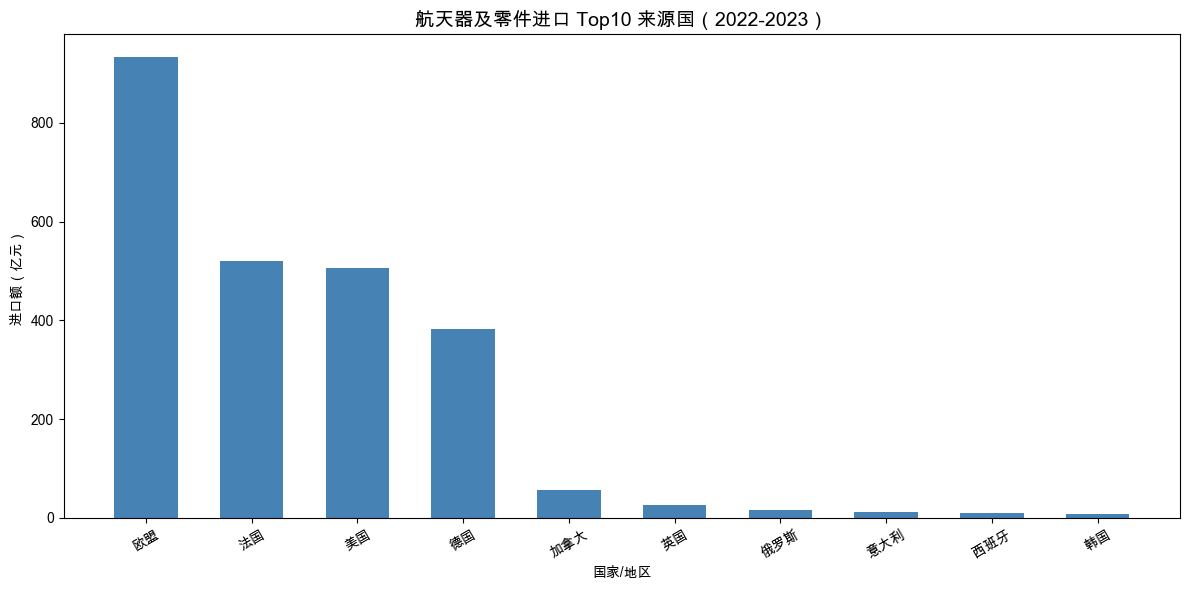

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]
df['年度合计'] = df[month_cols].sum(axis=1)

df_top10 = df[df['方向']=='进口额'].nlargest(10, '年度合计')

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_top10['国家'], df_top10['年度合计']/10000, color='steelblue', width=0.6)
ax.set_title('航天器及零件进口 Top10 来源国（2022-2023）', fontsize=14)
ax.set_xlabel('国家/地区')
ax.set_ylabel('进口额（亿元）')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 4.3 折线图：某国 24 个月趋势


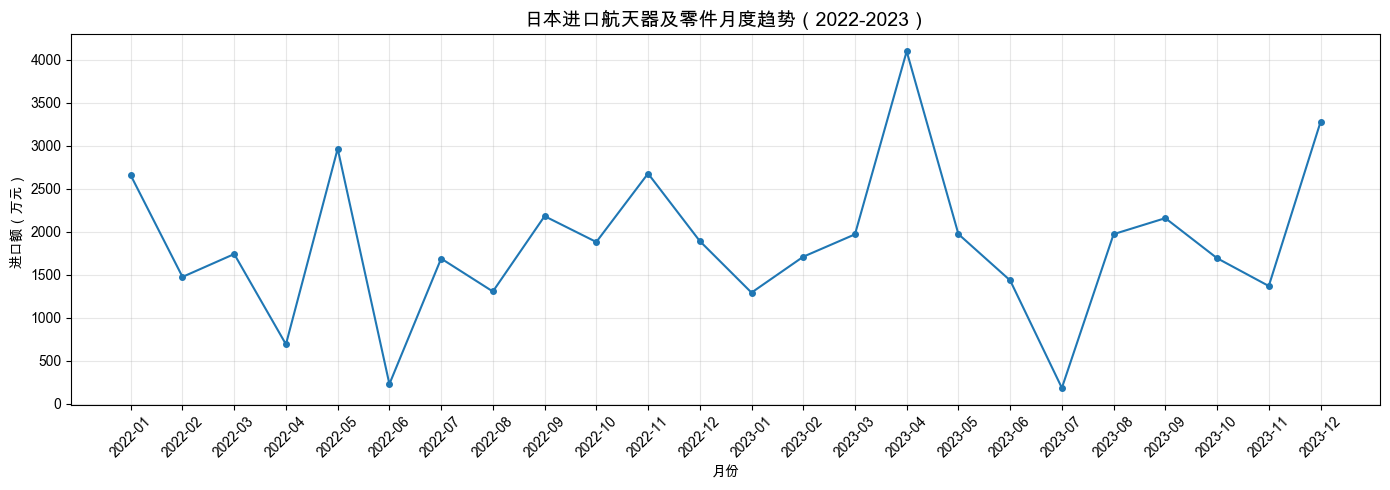

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]

# 提取日本进口数据
row = df[(df['国家']=='日本') & (df['方向']=='进口额')].iloc[0]
values = [row[c] for c in month_cols]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(month_cols, values, marker='o', markersize=4, linewidth=1.5, color='tab:blue')
ax.set_title('日本进口航天器及零件月度趋势（2022-2023）', fontsize=14)
ax.set_xlabel('月份')
ax.set_ylabel('进口额（万元）')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.4 箱线图：各国月度分布对比


/var/folders/8j/_jv21_yj3z35prvmn50wtjsh0000gn/T/ipykernel_56094/1394792566.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True, flierprops={'marker': 'o', 'color': 'red', 'markersize': 4})


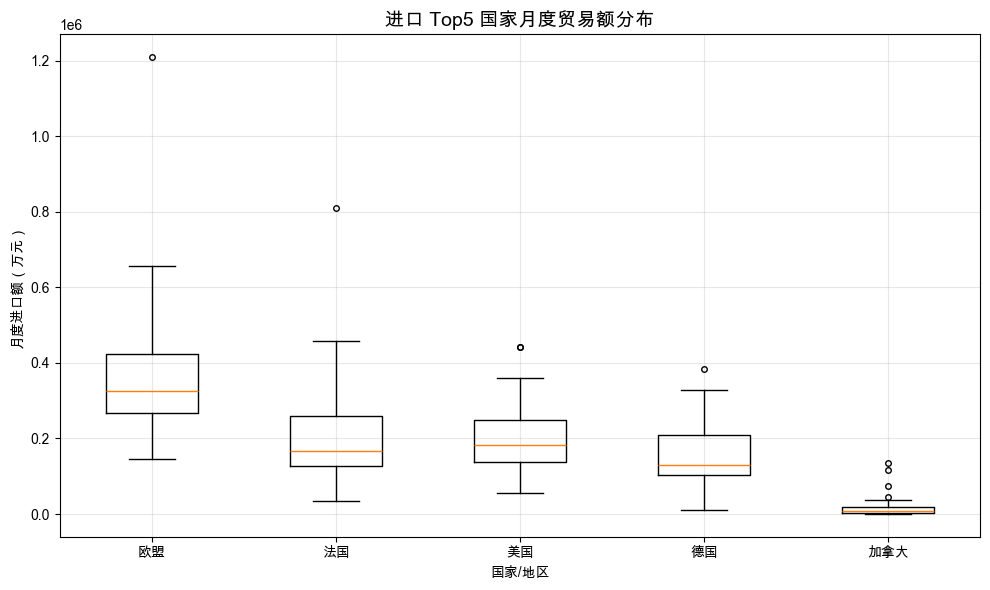

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]

# 选取进口 Top5 国家
df['年度合计'] = df[month_cols].sum(axis=1)
df_top5 = df[df['方向']=='进口额'].nlargest(5, '年度合计')

data = [df_top5.iloc[i][month_cols].dropna().tolist() for i in range(len(df_top5))]
labels = df_top5['国家'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, labels=labels, showfliers=True, flierprops={'marker': 'o', 'color': 'red', 'markersize': 4})
ax.set_title('进口 Top5 国家月度贸易额分布', fontsize=14)
ax.set_xlabel('国家/地区')
ax.set_ylabel('月度进口额（万元）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.5 多子图：plt.subplots(2,2)

一次绘制柱状图、折线图、直方图、箱线图四种图表。


/var/folders/8j/_jv21_yj3z35prvmn50wtjsh0000gn/T/ipykernel_56094/3574302692.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data, labels=df_top5['国家'].tolist())


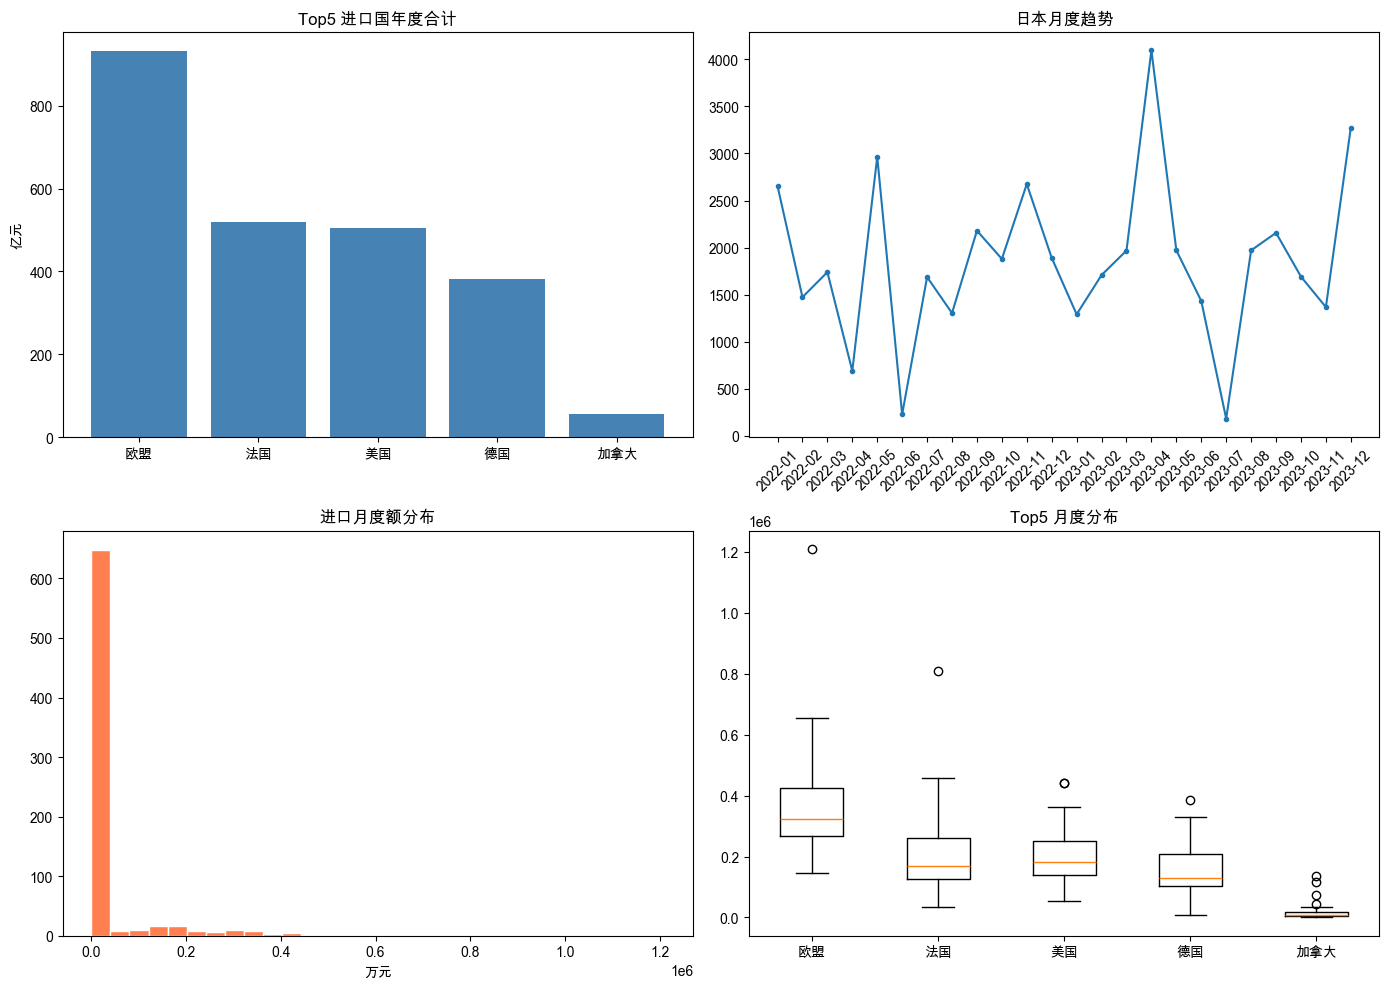

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]
df['年度合计'] = df[month_cols].sum(axis=1)

df_import = df[df['方向']=='进口额']
df_top5 = df_import.nlargest(5, '年度合计')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 柱状图
axes[0,0].bar(df_top5['国家'], df_top5['年度合计']/10000, color='steelblue')
axes[0,0].set_title('Top5 进口国年度合计')
axes[0,0].set_ylabel('亿元')

# 折线图
row = df[(df['国家']=='日本') & (df['方向']=='进口额')].iloc[0]
axes[0,1].plot(month_cols, [row[c] for c in month_cols], marker='o', markersize=3)
axes[0,1].set_title('日本月度趋势')
axes[0,1].tick_params(axis='x', rotation=45)

# 直方图
all_values = df_import[month_cols].values.flatten()
all_values = all_values[~pd.isna(all_values)]
axes[1,0].hist(all_values, bins=30, color='coral', edgecolor='white')
axes[1,0].set_title('进口月度额分布')
axes[1,0].set_xlabel('万元')

# 箱线图
data = [df_top5.iloc[i][month_cols].dropna().tolist() for i in range(len(df_top5))]
axes[1,1].boxplot(data, labels=df_top5['国家'].tolist())
axes[1,1].set_title('Top5 月度分布')

plt.tight_layout()
plt.show()


### 4.6 三轮迭代：科技感图表（两段式 Prompt + Inline Edit 综合演示）

**Round 1（氛围层）**：

```
用 Matplotlib 画一个现代感的进口 Top10 柱状图，科技感配色
```

**Round 2（约束层）**：

```
保持科技感风格，优化：
1) 深色背景 #1a1a2e
2) 柱子用蓝紫渐变
3) 添加数值标签
4) 中文字体
```

**Round 3（Inline Edit 细节打磨）**：
选中 `width` 参数 → `Cmd+K` → "柱子间距改为0.5，x轴标签旋转30度"
→ 查看 Diff → 列名正确？逻辑正确？边界处理？→ Accept


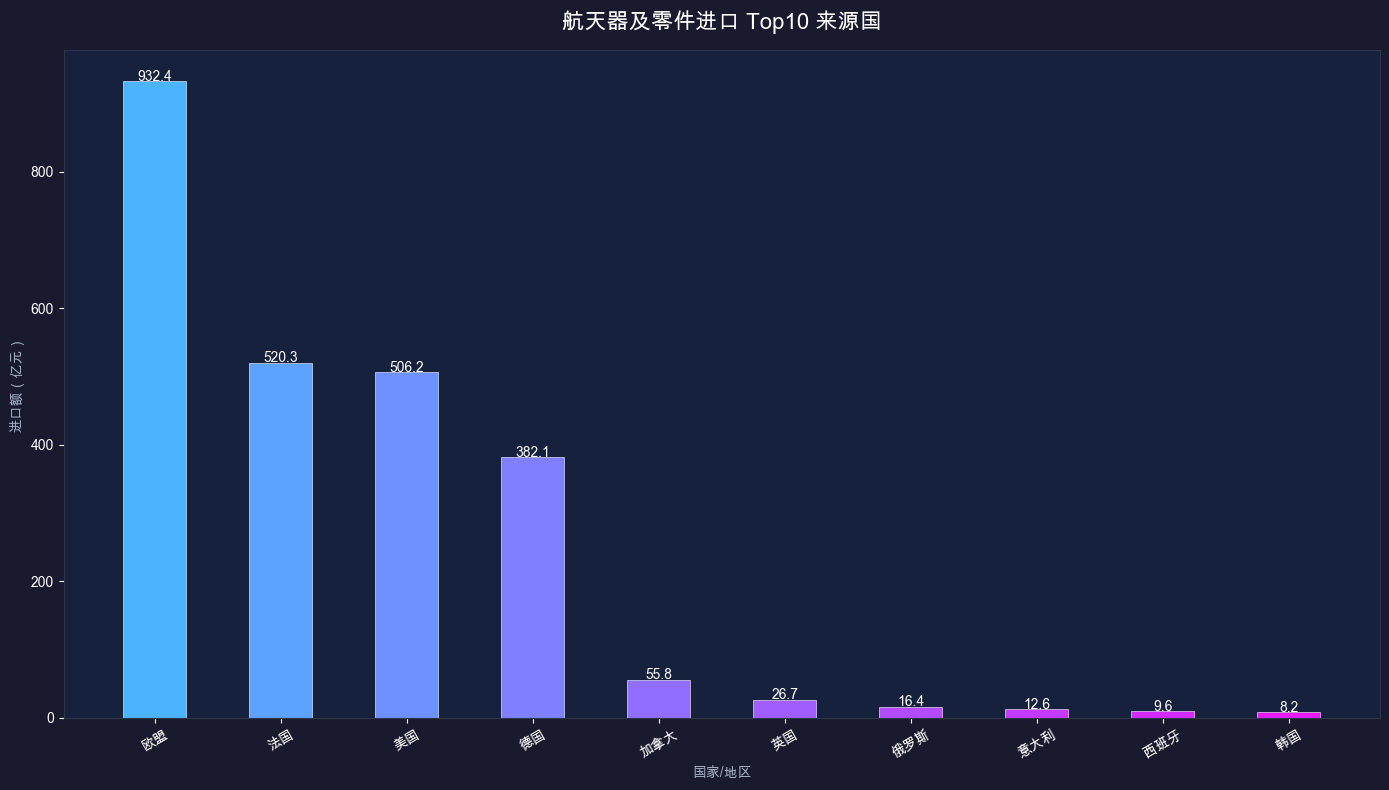

图表已保存为 进口Top10科技感.png ✓


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('实验一/航天进出口额.xlsx', sheet_name='Sheet0')
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)
month_cols = [c for c in df.columns if c.startswith('2022') or c.startswith('2023')]
df['年度合计'] = df[month_cols].sum(axis=1)

df_top10 = df[df['方向']=='进口额'].nlargest(10, '年度合计')

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

# 蓝紫渐变
colors = plt.cm.cool(np.linspace(0.3, 0.9, len(df_top10)))
bars = ax.bar(df_top10['国家'], df_top10['年度合计']/10000,
              color=colors, width=0.5, edgecolor='white', linewidth=0.4)

# 数值标签
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', color='white', fontsize=10)

ax.set_title('航天器及零件进口 Top10 来源国', color='white', fontsize=16, pad=15)
ax.set_xlabel('国家/地区', color='#a0aec0')
ax.set_ylabel('进口额（亿元）', color='#a0aec0')
ax.tick_params(colors='white')
plt.xticks(rotation=30)
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3748')

plt.tight_layout()
plt.savefig('进口Top10科技感.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('图表已保存为 进口Top10科技感.png ✓')


---

## Part 5：工程化进阶全景

**本 Part 为方法论讲解，无需运行代码，重在理解每个工具解决什么问题。**

### 5.1 MCP 能力扩展

**问题**：AI 只能看你给它的文件，无法访问数据库、外部 API、实时数据。

**MCP（Model Context Protocol）**：Anthropic 提出的开放标准，让 AI 直接连接外部服务。

| MCP Server       | Pandas 场景用途                      |
| ---------------- | ------------------------------------ |
| `sqlite-mcp`     | 直接读数据库表，生成 `read_sql` 代码 |
| `filesystem-mcp` | 批量扫描目录下所有 CSV/Excel         |
| `pandas-mcp`     | 直接在 AI 对话中执行 DataFrame 操作  |
| `github-mcp`     | 自动从 GitHub 拉取数据集             |

**配置示例**（`.codebuddy/mcp.json`）：

```json
{
  "mcpServers": {
    "sqlite": {
      "command": "npx",
      "args": ["-y", "@modelcontextprotocol/server-sqlite", "贸易.db"]
    }
  }
}
```

配置后直接在 CodeBuddy 对话：

```
帮我查询进口表中年度合计前10的国家，生成 pandas 代码
```

---

### 5.2 Agent Skills —— 封装可复用 SOP

**问题**：同样的 Prompt 每次要重新写，团队协作没有统一"口令"。

**Agent Skills**：给 AI 配的"固定招式/SOP"——一遇到某类任务就自动按规定流程做。

**SKILL.md 结构**：

```markdown
---
name: trade-analyze
description: "分析航天贸易数据，生成进口 Top10 报告和可视化"
---

## 执行步骤

1. 读取 Excel 文件（sheet_name='Sheet0'）
2. 解析指标列，拆出方向/国家
3. 筛选进口，计算年度合计
4. 生成 Top10 柱状图，保存为 PNG
5. 将结果写入 CSV（utf-8-sig）

## 约束

- 禁止 for 循环
- 必须有 try/except 处理文件不存在的情况
- 图表必须有标题和中文轴标签
```

**配置路径**：`.codebuddy/skills/trade-analyze/SKILL.md`

触发方式：在 CodeBuddy 中直接描述"分析这份航天贸易数据"，AI 自动加载 Skill 按 SOP 执行。

---

### 5.3 自定义斜杠指令（Slash Commands）

**问题**：高频操作每次手动触发，多步骤操作容易遗漏。

**自定义 `/` 指令**：把常用 Prompt + 工作流封装成一条命令。

**配置路径**：`.codebuddy/commands/trade-report.md`

```yaml
---
name: trade-report
description: "一键生成航天贸易分析报告（读取→处理→可视化→保存）"
---

## 执行流程

1. 检查当前目录是否有 航天进出口额.xlsx
2. 读取 Sheet0，执行标准贸易处理流程
3. 生成 Top10 柱状图保存为 PNG
4. 输出 进口Top10.csv

## 约束

- 遵循 Rules 中的所有编码规范
- 操作前确认文件存在，不存在则提示用户
```

触发方式：在 CodeBuddy 中输入 `/trade-report`，AI 一键完成全流程。

**CodeBuddy 内置斜杠指令速查**：

| 指令         | 用途                    |
| ------------ | ----------------------- |
| `/cr`        | 代码审查（Code Review） |
| `/explain`   | 解释选中代码            |
| `/tests`     | 生成单元测试            |
| `/fix`       | 修复代码问题            |
| `/rules`     | 自动生成 Rules 文件     |
| `/summarize` | 总结历史对话            |


---

## 小结

### Pandas 知识点速查表

| 操作 | 代码 |
|---|---|
| 创建 Series | `pd.Series({'北京': 89, '上海': 45, ...})` |
| 创建 DataFrame | `pd.DataFrame({'产品': [...], '一季度': [...]})` |
| 读取 Excel | `pd.read_excel('f.xlsx', sheet_name='Sheet0')` |
| 选列 | `df['一季度']` / `df[['产品','一季度']]` |
| 条件筛选 | `df[df['方向'] == '进口额']` |
| 排序 | `df.sort_values('季度合计', ascending=False)` |
| 新增列 | `df['季度合计'] = df['一季度'] + df['二季度'] + df['三季度']` |
| 分组聚合 | `df.groupby('方向').agg(['sum','mean'])` |
| 宽转长 | `df.melt(id_vars, value_vars, var_name, value_name)` |
| 缺失值填充 | `df['列'].fillna(df['列'].median())` |
| 写回 CSV | `df.to_csv('out.csv', index=False, encoding='utf-8-sig')` |
| 滚动窗口 | `s.rolling(3).mean()` |

### Vibe Coding 工具速查表

| 工具 | 触发方式 | 解决的核心问题 |
|------|---------|--------------|
| **两段式 Prompt** | 第一句描述氛围，第二句加约束 | AI 输出方向跑偏 |
| **Rules 文件** | `.codebuddy/rules/python-style.md` | 每次生成风格不一致 |
| **@文件引用** | 对话框输入 `@文件名` | AI 不了解你的数据结构 |
| **上下文四层级** | 系统层/会话层/指令层/隐式层 | 上下文噪声太多/太少 |
| **Inline Edit** | 选中代码 → `Cmd+K` | 小改动打断心流 |
| **Diff 审查** | 三步：列名/逻辑/边界 | 盲目 Accept 引入 bug |
| **MCP** | `.codebuddy/mcp.json` 配置 | AI 无法访问外部数据 |
| **Agent Skills** | `.codebuddy/skills/` 目录 | 重复 SOP 每次重写 |
| **斜杠指令** | `/trade-report`，`.codebuddy/commands/` | 高频流程手动触发 |

### 三个危险信号（自查）

| 信号 | 说明 | 对策 |
|------|------|------|
| 手动改 AI 代码 | 退回"代码工人"模式 | 用自然语言说清楚，让 AI 改 |
| 去搜索语法细节 | 陷入旧思路时间黑洞 | 把问题描述给 AI |
| 觉得描述需求比写代码慢 | 表达方式还在适应期 | 坚持"先目标、后约束" |

---

> **本讲核心公式**：
> AI 输出质量 = f(上下文精准度) × f(约束清晰度)
>
> 你的工作 = 提供精准的上下文 + 清晰的约束 + 审查 Diff